In [1]:
import pathlib
import random

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
import xarray as xr

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
tfrecord_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run2')
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
vmins = [0, -1, -1, 0, 0, 0]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
boundary_variables = ["hs_bnd", "hswe_bnd", "tmm10_bnd"]
variable_fields = input_variables + output_variables + boundary_variables

min_max_values = xr.open_dataset(tfrecord_dir / "min-max-values/min-max-values-all.nc")

for bnd_var in boundary_variables:
    min_max_values[bnd_var] = min_max_values[bnd_var.split("_")[0]]

min_max_values["theta0_x"] = xr.DataArray(np.array([-1, 1.]), dims='index')
min_max_values["theta0_y"] = xr.DataArray(np.array([-1, 1.]), dims='index')

In [3]:
learning_rate = 1e-4
n_epochs = 100
batch_size = 16
steps_per_execution = 1

model_version = "swan_ens_nn_v0005"

src_dir = pathlib.Path().resolve().parent
model_dir = src_dir / f"trained_models/{model_version}"
model_dir.mkdir(exist_ok=True, parents=True)

figure_dir = model_dir / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

raster_shape = (481, 421, 2)
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

In [5]:
def get_files(data_path):
    files = tf.io.gfile.glob(data_path + "/" + "*.tfrecords")
    return files


def get_dataset(files):
    """return a tfrecord dataset with all tfrecord files"""
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(tf_parse)
    return dataset


def tf_parse(eg, variable_fields=variable_fields):
    """parse an example (or batch of examples, not quite sure...)"""

    # here we re-specify our format
    # you can also infer the format from the data using tf.train.Example.FromString
    # but that did not work
    parse_dict =         {
            "height": tf.io.FixedLenFeature([], tf.int64),
            "width": tf.io.FixedLenFeature([], tf.int64),
            "depth": tf.io.FixedLenFeature([], tf.int64),
        }

    vars = variable_fields
    for var in vars:
        parse_dict[var] = tf.io.FixedLenFeature([], tf.string)

    example = tf.io.parse_example(
        eg[tf.newaxis],
        parse_dict,
    )

    variables = {}
    for var in variable_fields:
        variables[var] = tf.io.parse_tensor(example[var][0], out_type="float32")
        # variables[var] = (variables[var] - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])
        # variables[var] = tf.where(tf.math.is_nan(variables[var]), tf.zeros_like(variables[var]) - 1, variables[var])
        if var in output_variables:
            variables[var] = variables[var][..., -1]
            variables[var] = tf.reshape(variables[var], (481, 421, 1))
        else:
            variables[var] = (variables[var] - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])
        variables[var] = tf.where(
            tf.math.is_nan(variables[var]),
            tf.zeros_like(variables[var]) - 9,
            variables[var],
        )


    variables["hs_bnd"] = tf.reshape(variables["hs_bnd"], (22, 1))
    variables["tmm10_bnd"] = tf.reshape(variables["tmm10_bnd"], (22, 1))
    variables["hswe_bnd"] = tf.reshape(variables["hswe_bnd"], (22, 1))

    image_inputs = tf.concat([variables[var] for var in input_variables], axis=-1)
    
    boundary_inputs = tf.concat([variables["hs_bnd"], variables["tmm10_bnd"], variables["hswe_bnd"]], axis=-1)

    inputs = (variables["xwnd"], variables["ywnd"], variables["ssh"], variables["xcur"], variables["ycur"], boundary_inputs)
    inputs = (image_inputs, boundary_inputs)
    outputs = (variables["hs"], variables["theta0_x"], variables["theta0_y"], variables["tmm10"], variables["tps"], variables["hswe"])
    outputs = tf.concat([variables[var] for var in output_variables], axis=-1)

    return inputs, outputs

In [5]:
# Get dataset and shuffle
random.seed(0)
files = get_files(str(tfrecord_dir))
random.shuffle(files)
files = files[-100:]
dataset = get_dataset(files)
# Filter out all samples with high values
# dataset = dataset.filter(lambda x, y: tf.reduce_all(x <= 1))
# dataset = dataset.filter(lambda x, y: tf.reduce_all(y <= 10))

train_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .take(int(0.7 * len(files) * 10))
    .batch(batch_size, drop_remainder=True)
)
test_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .skip(int(0.7 * len(files) * 10))
    .batch(batch_size, drop_remainder=True)
)

2024-10-21 08:16:32.425118: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2024-10-21 08:16:32.425234: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn147.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist


In [6]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'))
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 481, 421, 1  0           []                               
                                0)]                                                               
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 512, 512, 10  0          ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 512, 512, 10  40         ['zero_padding2d[0][0]']         
 alization)                     )                                                             

2024-10-21 08:43:43.482078: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:392] Filling up shuffle buffer (this may take a while): 415 of 1000
2024-10-21 08:43:53.512690: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:392] Filling up shuffle buffer (this may take a while): 836 of 1000
2024-10-21 08:43:57.212532: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:417] Shuffle buffer filled.


1/1 [==============================] - 17s 17s/step
(16, 481, 421, 6)


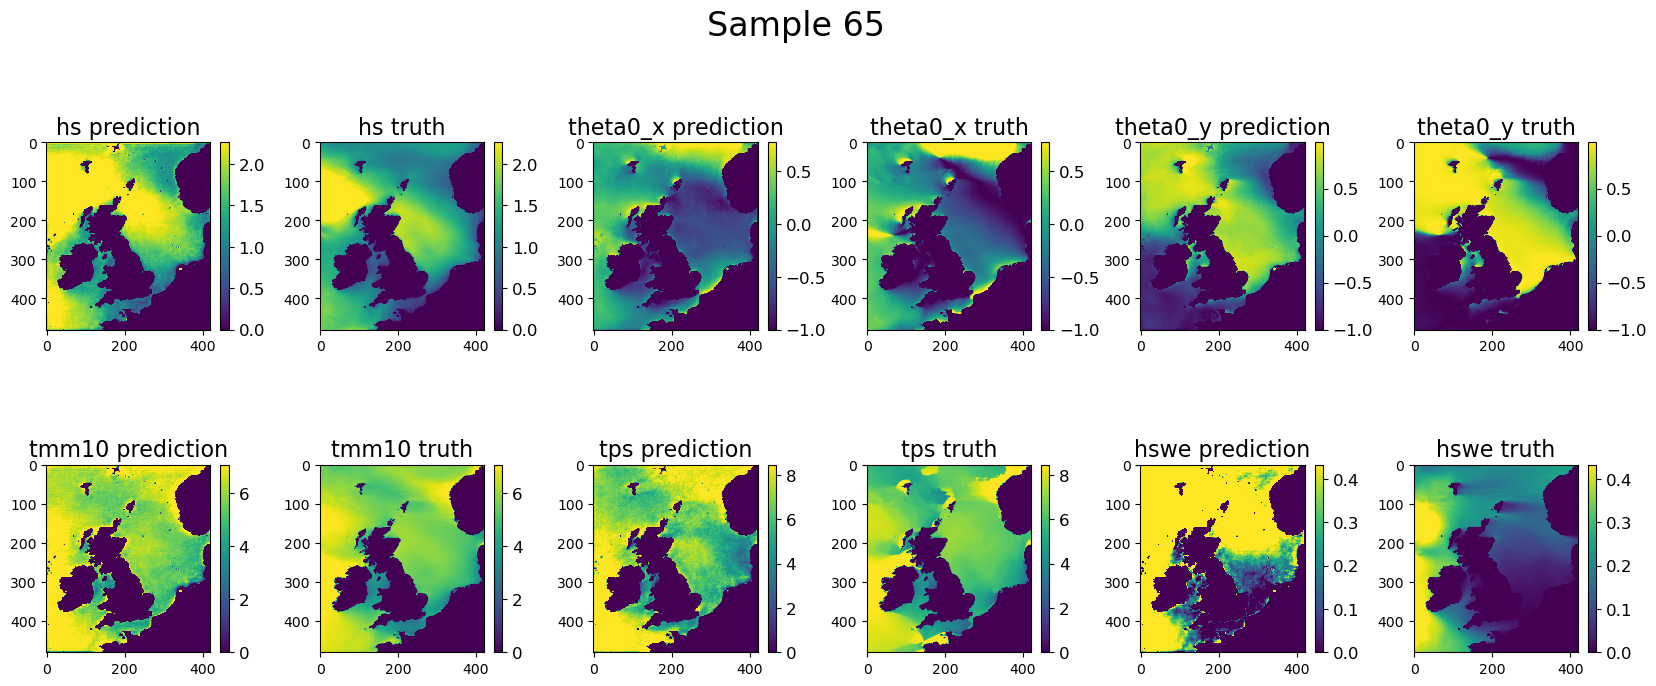

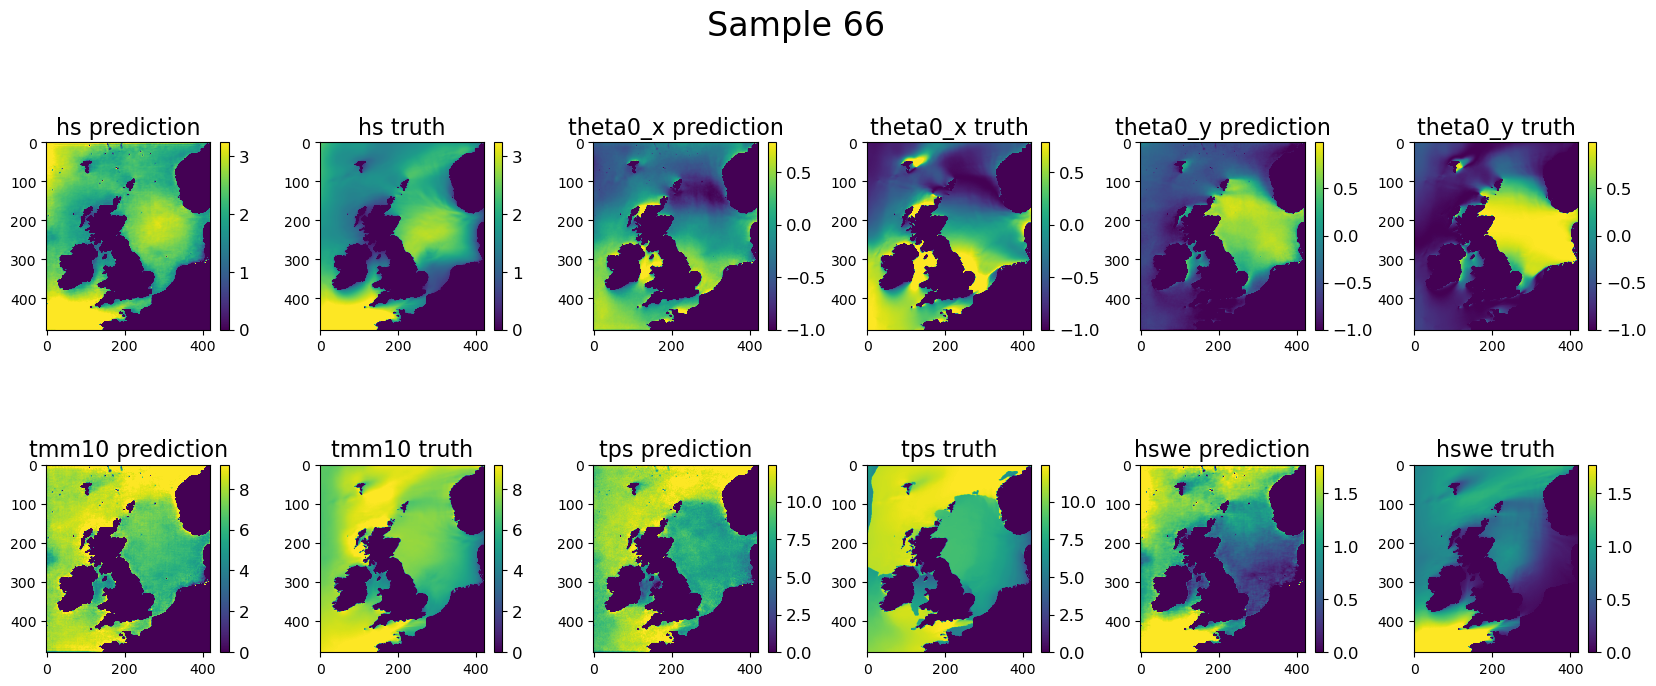

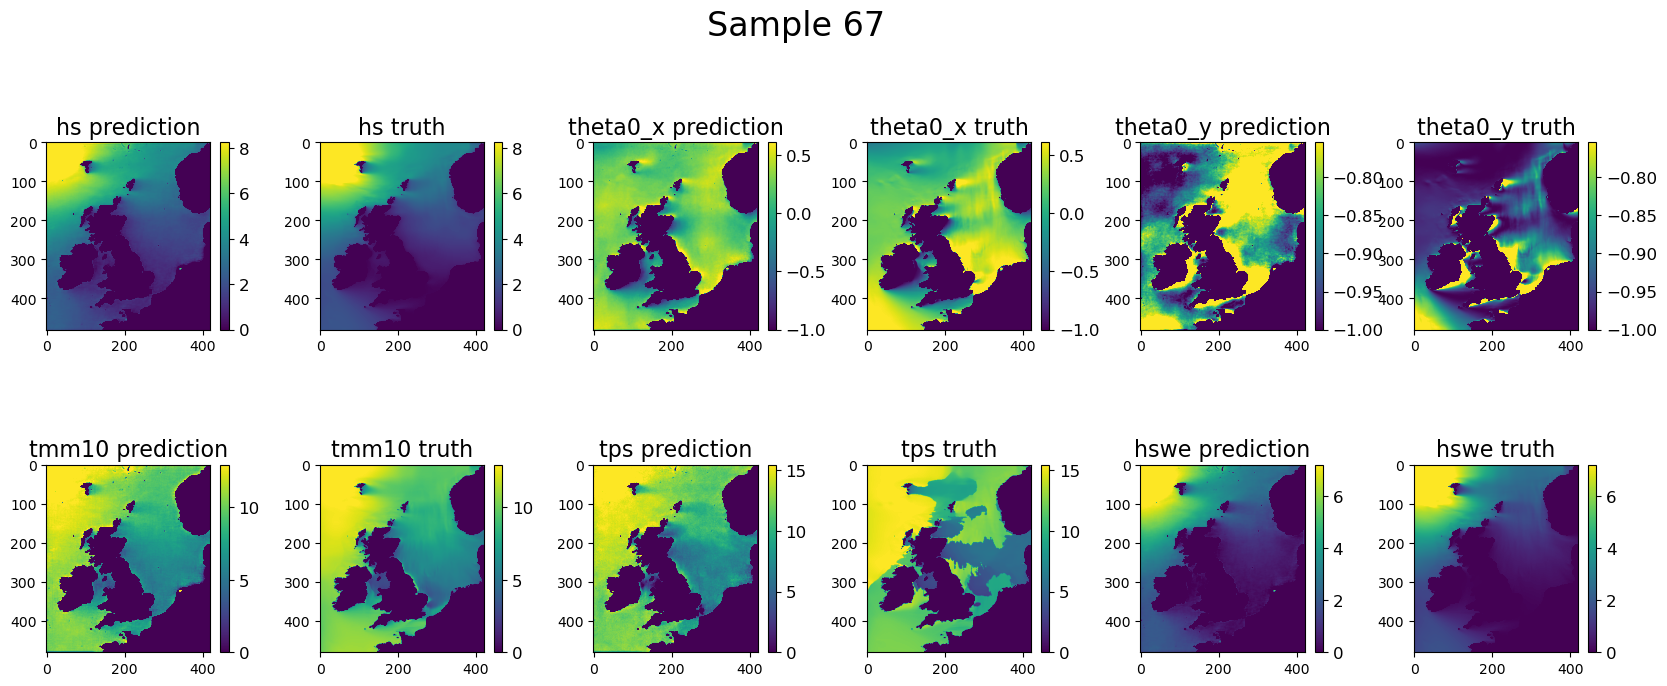

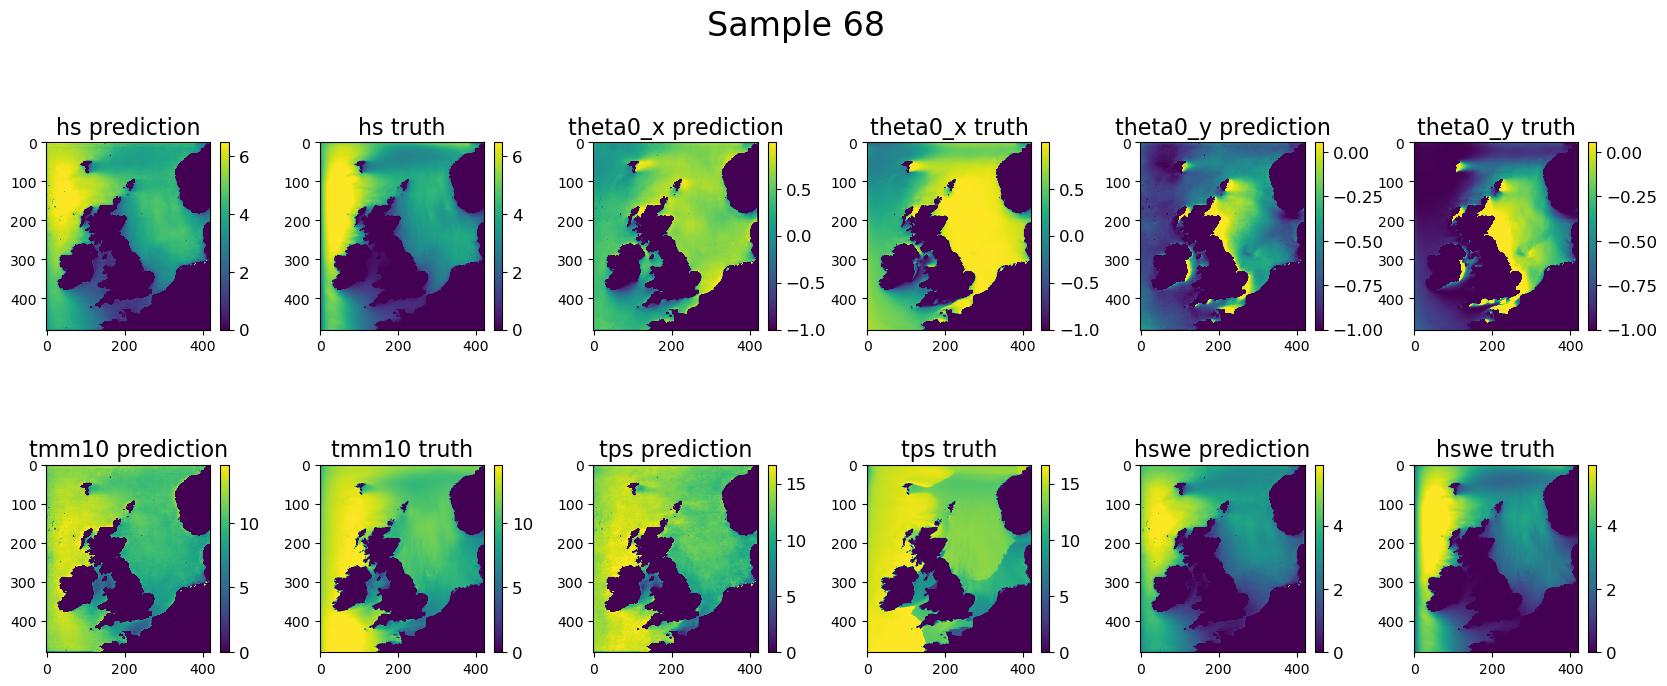

In [17]:
skip_count = 4
for i, o in test_dataset.skip(skip_count).take(1):
    o_pred = model.predict(i)
    print(o_pred.shape)
    for j, var in enumerate(output_variables):
        o_pred[..., j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[..., j] + min_max_values[var].values[0]

    o_pred = np.flip(o_pred, axis=1)
    o = np.flip(o, axis=1)
        
    for k in range(4):
        sample = skip_count * batch_size + k
        fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(20, 8))
        fig.suptitle(f'Sample {sample + 1}', fontsize=24)
        plt.subplots_adjust(wspace=0.5, hspace=0.1)
        for j, var in enumerate(output_variables):
            vmin, vmax = np.percentile(o[k, ... , j], (5, 95))
            # vmin, vmax = (-1, 1)
            vmin = vmins[j]

            column = j % 3
            row = j // 3
            
            im_pred = axes[row, 2 * column].imshow(o_pred[k, ..., j], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[row, 2 * column])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)
            cb.ax.tick_params(labelsize=12)
            cb.ax.yaxis.get_offset_text().set(size=12)
            
            axes[row, 2 * column].set_title(f"{var} prediction", size=16)
            
            im_truth = axes[row, 2 * column + 1].imshow(o[k, ..., j], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[row, 2 * column + 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_truth, cax=cax)
            cb.ax.tick_params(labelsize=12)
            cb.ax.yaxis.get_offset_text().set(size=12)

            axes[row, 2 * column + 1].set_title(f"{var} truth", size=16)

        
        plt.savefig(figure_dir / f"sample-{sample + 1}-predictions.png")
            

2024-10-21 08:44:36.575490: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:392] Filling up shuffle buffer (this may take a while): 724 of 1000
2024-10-21 08:44:40.386405: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:417] Shuffle buffer filled.


1/1 [==============================] - 17s 17s/step


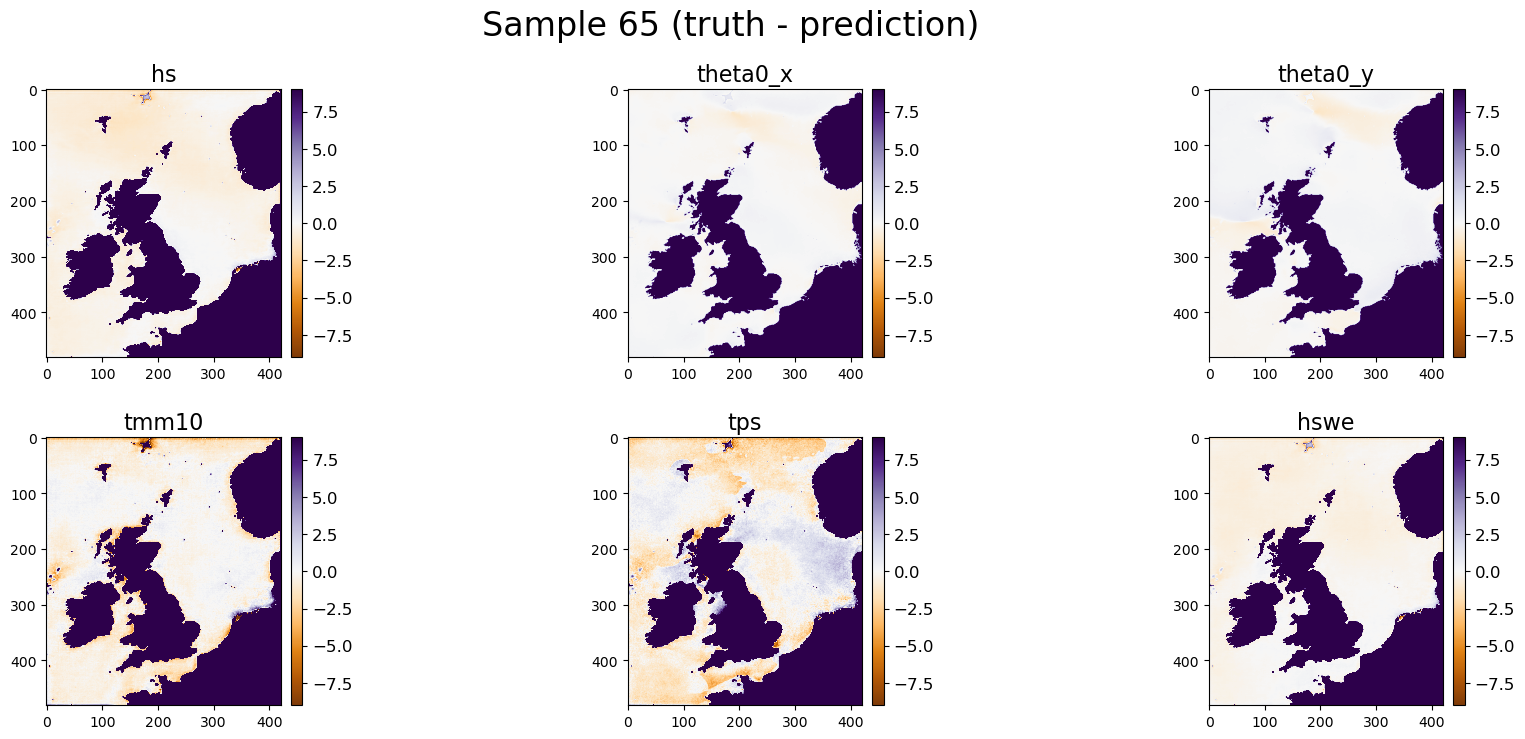

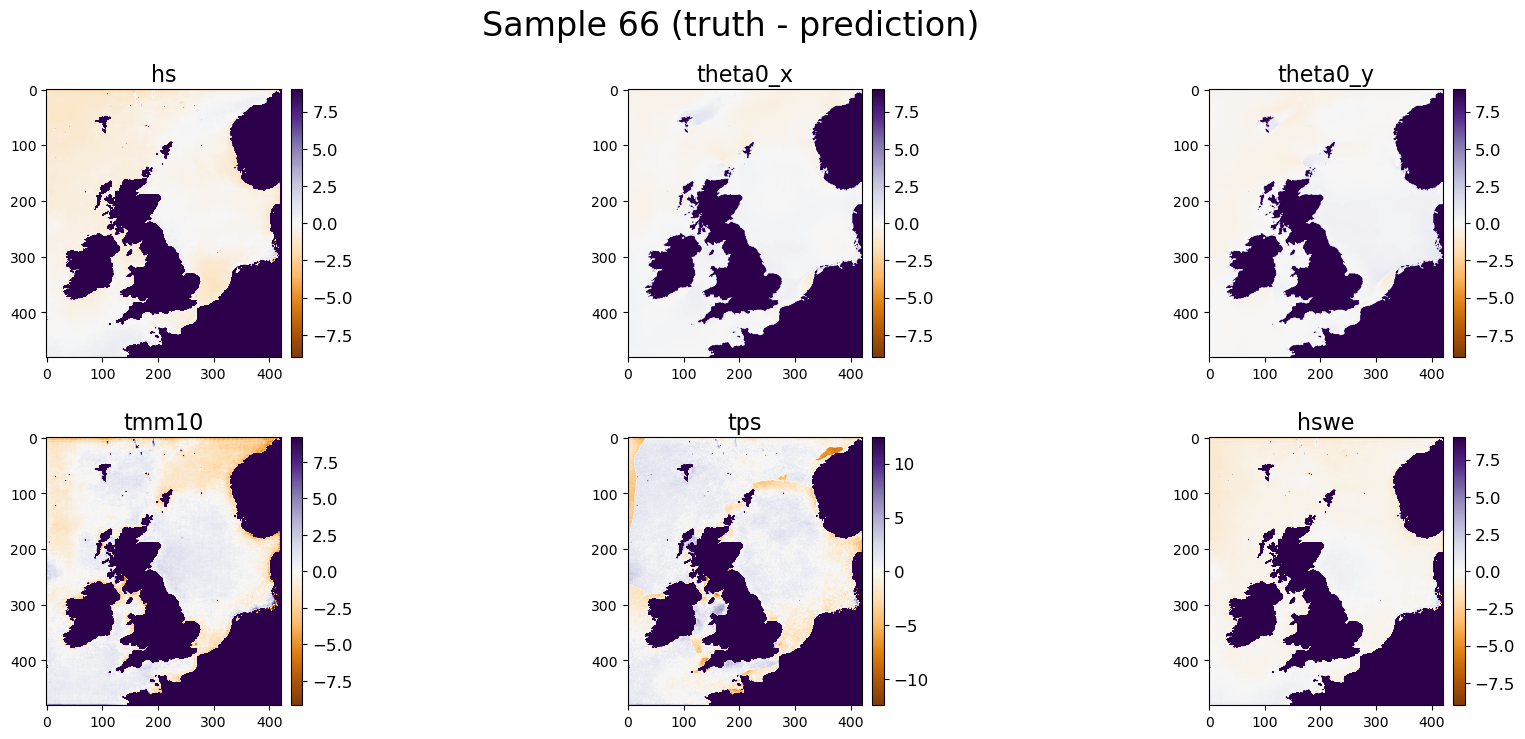

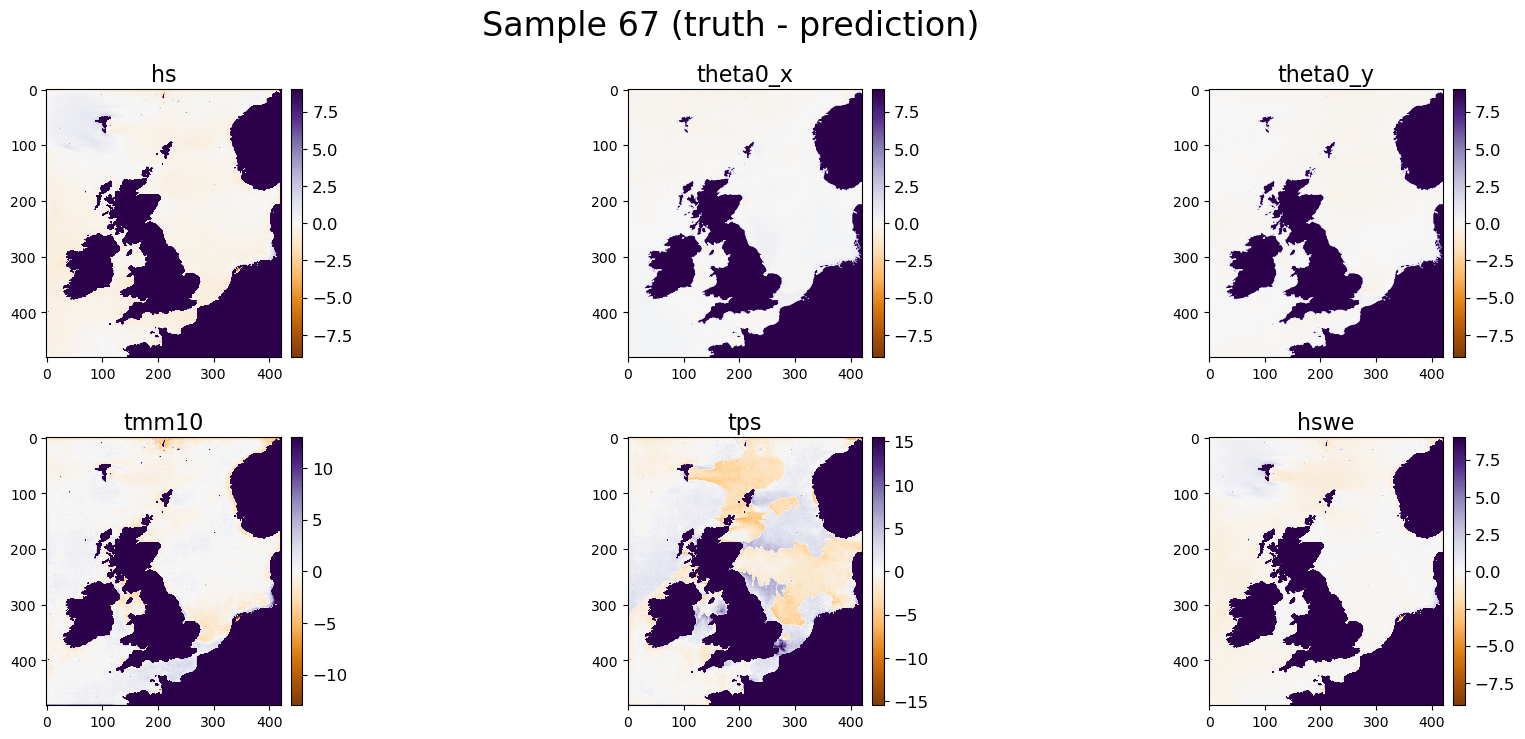

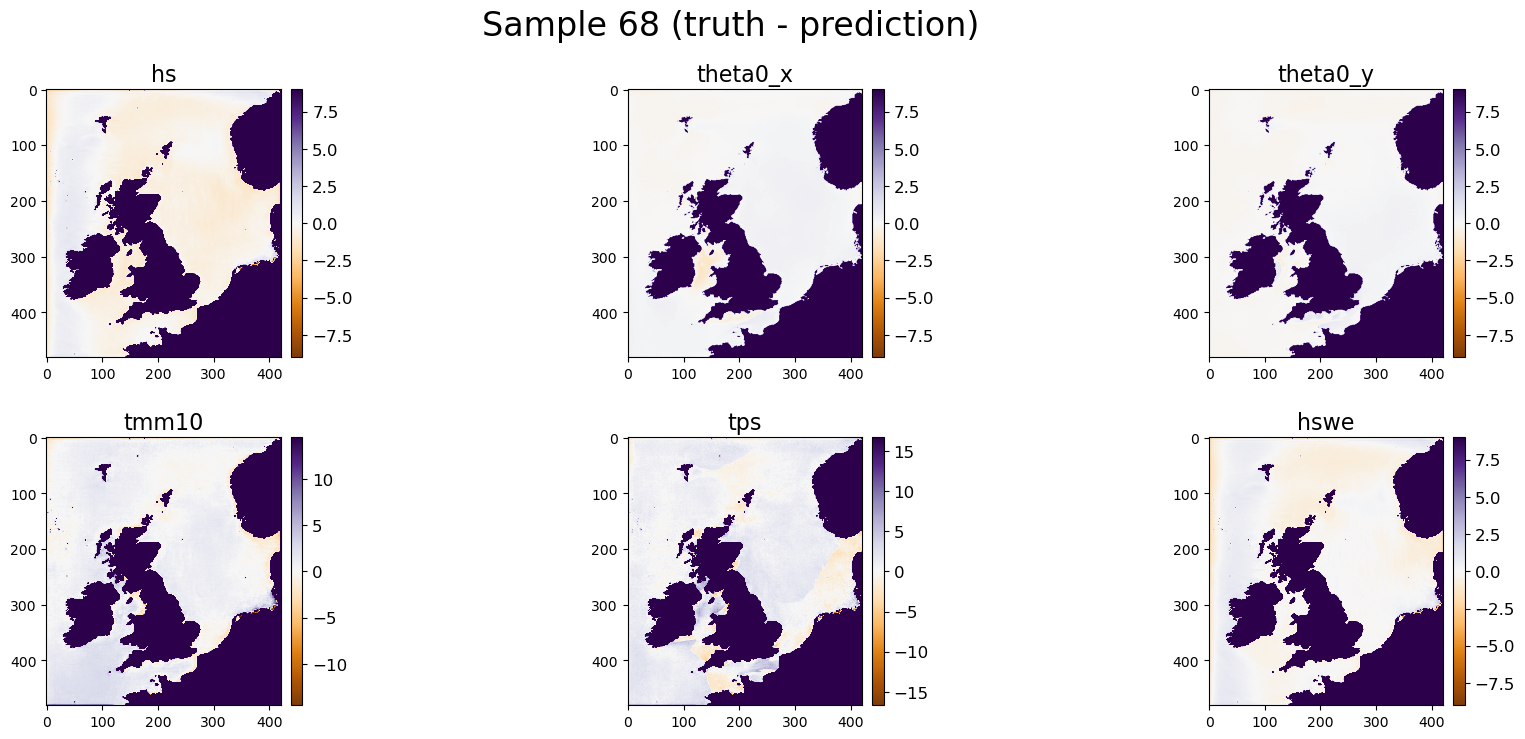

In [18]:
for i, o in test_dataset.skip(skip_count).take(1):
    o_pred = model.predict(i)
    for j, var in enumerate(output_variables):
        o_pred[..., j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[..., j] + min_max_values[var].values[0]

    o_pred = np.flip(o_pred, axis=1)
    o = np.flip(o, axis=1)
    
    for k in range(4):
        sample = batch_size * skip_count + k
        fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(20, 8))
        fig.suptitle(f'Sample {sample + 1} (truth - prediction)', fontsize=24)
        plt.subplots_adjust(wspace=0.5, hspace=0.3)
        for j, var in enumerate(output_variables):
            vmin, vmax = np.percentile(o[k, ... ,j], (5, 95))
            vmax = np.max([abs(vmin), abs(vmax)]) 
            vmin = -vmax

            column = j % 3
            row = j // 3

            diff = o[k, ..., j] - o_pred[k, ..., j]
            
            im_pred = axes[row, column].imshow(diff, vmin=vmin, vmax=vmax, cmap='PuOr')
            divider = make_axes_locatable(axes[row, column])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)
            cb.ax.tick_params(labelsize=12)
            cb.ax.yaxis.get_offset_text().set(size=12)
            
            axes[row, column].set_title(f"{var}", size=16)

        plt.savefig(figure_dir / f"sample-{sample + 1}-predictions-differences.png")
            

In [15]:
a = "[32, 64, 128, 256, 512]"

In [17]:
import ast

In [18]:
ast.literal_eval(a)

[32, 64, 128, 256, 512]